In [1]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 5e-1*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

# Example
price = black_scholes_call(100, 100, 1, 0.05, 0.2)
print("Call Price:", price)

Call Price: 10.450583572185565


In [2]:
def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

print("Delta:", delta_call(100,100,1,0.05,0.2))
print("Gamma:", gamma(100,100,1,0.05,0.2))

Delta: 0.6368306511756191
Gamma: 0.018762017345846895


In [9]:
from scipy.optimize import bisect

def implied_volatility(market_price, S, K, T, r):
    def difference(sigma):
        return black_scholes_call(S, K, T, r, sigma) - market_price
    return bisect(difference, 0.001, 3)

iv = implied_volatility(10, 100, 100, 1, 0.05)
print("Implied Volatility:", iv)

Implied Volatility: 0.1879716494572681


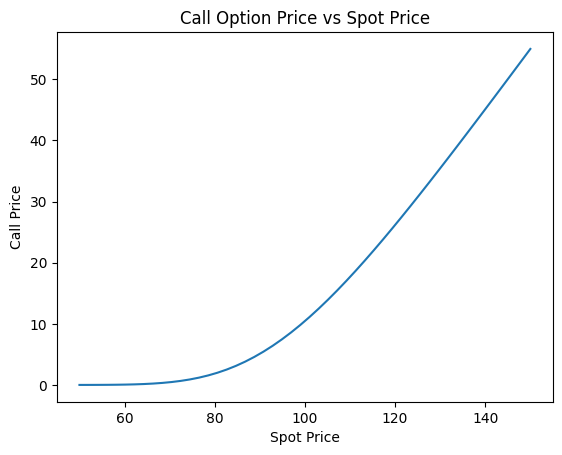

In [4]:
import matplotlib.pyplot as plt

S_values = np.linspace(50, 150, 50)
prices = []

for S in S_values:
    prices.append(black_scholes_call(S, 100, 1, 0.05, 0.2))

plt.plot(S_values, prices)
plt.title("Call Option Price vs Spot Price")
plt.xlabel("Spot Price")
plt.ylabel("Call Price")
plt.show()

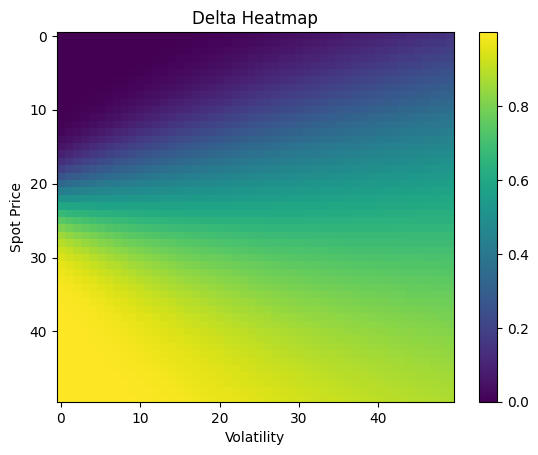

In [5]:
import matplotlib.pyplot as plt

S_values = np.linspace(50, 150, 50)
sigma_values = np.linspace(0.1, 0.5, 50)

delta_matrix = np.zeros((len(S_values), len(sigma_values)))

for i, S in enumerate(S_values):
    for j, sigma in enumerate(sigma_values):
        delta_matrix[i,j] = delta_call(S, 100, 1, 0.05, sigma)

plt.imshow(delta_matrix, aspect='auto')
plt.colorbar()
plt.title("Delta Heatmap")
plt.xlabel("Volatility")
plt.ylabel("Spot Price")
plt.show()